# Exercise 1: PD Control of Inverted Pendulum

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import jax
import jax.numpy as jnp

### Inverted Pendulum Dynamics

The dynamics for a controlled inverted pendulum is defined by the second order equation:
\begin{equation}
\ddot{\theta} = \frac{g}{l}\sin\theta + \frac{1}{ml^2}u,
\end{equation}
where $\theta$ is the angle of the pendulum with respect to the positive vertical axis, $g$ is the acceleration due to gravity, $l$ is the length of the pendulum, $m$ is the pendulum mass, and $u$ is the control input (a torque about the axis of rotation).

The linearized approximation to these dynamics are simply:
\begin{equation}
\ddot{\theta} = \frac{g}{l}\theta + \frac{1}{ml^2}u.
\end{equation}

A simple PD controller for this system could take the form:
\begin{equation}
u = k_p\theta + k_d \dot{\theta},
\end{equation}
which would give linear closed-loop dynamics:
\begin{equation}
\begin{bmatrix} 
\dot{\theta} \\ \ddot{\theta}
\end{bmatrix} =
\begin{bmatrix} 
0 & 1 \\ \frac{g}{l} + \frac{1}{ml^2}k_p & \frac{1}{ml^2}k_d
\end{bmatrix}
\begin{bmatrix} 
\theta \\ \dot{\theta}
\end{bmatrix}
\end{equation}

### Exercise 1.1: Implement the PD controller and the closed-loop inverted pendulum dynamics

In [2]:
def inverted_pendulum_controller(x: jnp.array, kp: float, kd: float) -> float:
    """
    Evaluate closed-loop inverted pendulum PD controller.

    Args:
        x: state vector, [θ, dθ_dt]
        kp: proportional gain
        kd: derivative gain

    Returns:
        u: control input for inverted pendulum
    """
    θ, dθ = x

    # Implement the PD controller below:
    ##### YOUR CODE STARTS HERE #####
    u = kp * θ + kd * dθ
    ###### YOUR CODE ENDS HERE ######
    return u

In [3]:
def closed_loop_inverted_pendulum(x: jnp.array, 
                                  t: float, 
                                  kp: float, 
                                  kd: float, 
                                  g: float=9.81, 
                                  m: float=1., 
                                  l: float=1.) -> jnp.array:
    """
    Evaluate closed-loop inverted pendulum dynamics.

    Args:
        x: state vector, [θ, dθ_dt]
        t: time [s]
        kp: proportional gain
        kd: derivative gain
        g: acceleration due to gravity [m/s^2]
        m: mass [kg]
        l: pendulum length [m]

    Returns:
        State vector derivative, dx/dt = [dθ_dt, d2θ_dt2]
    """
    θ, dθ = x

    # Compute control input
    u = inverted_pendulum_controller(x, kp, kd)

    # Apply the control to the dynamics
    ##### YOUR CODE STARTS HERE #####
    # Note: Use JAX numpy functions (jnp)
    dθ2 = (g / l) * jnp.sin(θ) + (1 / (m * l**2)) * u
    dx_dt = jnp.array([dθ, dθ2])
    ###### YOUR CODE ENDS HERE ######
    return dx_dt

### Exercise 1.2: Linearize the closed-loop dynamics, tune gains, and verify eigenvalues

In [4]:
# Linearize around the stationary upright position with zero control
# (i.e. the pendulum is perfectly balanced)
x_eq = jnp.array([0., 0.])

# Tune these gains to ensure the linear system is stable
kp = -10.
kd = -0.5

# Use JAX to compute the Jacobian, f_jac, of closed_loop_inverted_pendulum at x_eq
##### YOUR CODE STARTS HERE #####
f_jac = jax.jacfwd(
    lambda x, t: closed_loop_inverted_pendulum(x, t, kp, kd)
)
###### YOUR CODE ENDS HERE ######
A = f_jac(x_eq, 0) # Evaluate Jacobian at equilibrium point
print(A)

# Compute the eigenvalues of the Jacobian, and verify they are stable (negative real parts)
eig_vals, eig_vecs = np.linalg.eig(A)
print(eig_vals)

[[ 0.          1.        ]
 [-0.18999958 -0.5       ]]
[-0.25+0.35707083j -0.25-0.35707083j]


### Exercise 1.3: Simulate nonlinear closed-loop dynamics
Run the code below to simulate the nonlinear closed-loop dynamics using the tuned PD controller.

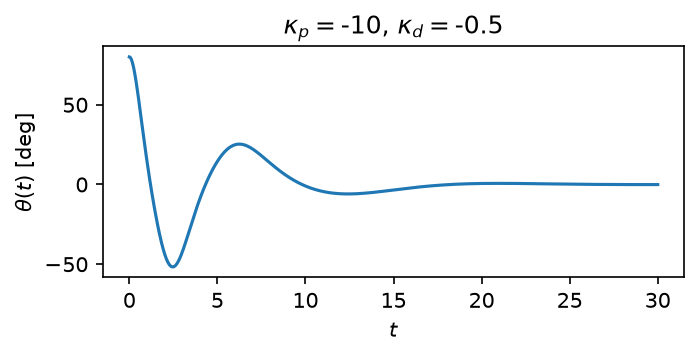

In [5]:
θ0 = np.deg2rad(80.)
x0 = np.array([θ0, 0.])
T = 30.

t = np.linspace(0, T, num=1000)
x = odeint(closed_loop_inverted_pendulum, x0, t, args=(kp, kd))
θ, dθ = x.T

fig, ax = plt.subplots(1, 1, figsize=(5, 2), dpi=150)
ax.plot(t, np.rad2deg(θ))
ax.set_title(r'$\kappa_p = $' + f'{kp:g}, ' + r'$\kappa_d = $' + f'{kd:g}')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\theta(t)$ [deg]')
plt.show()